In [1]:
import sys
sys.path.insert(0, "/home/claude")
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries, propagate2
import headway_integration_copy as hi
import numpy as np
from collections import defaultdict


In [2]:
def reassign_trip_ids_by_departure(trip_data, first_station="ME", second_station="MAL", save_path=None):
    entries_first = []
    entries_second = []
    entries_other = []

    for old_id, stops in trip_data.items():
        if not stops:
            continue
        first_stop = stops[0][0]
        # prefer explicit departure time at index 2, fallback to index 1
        dep_time = None
        if len(stops[0]) > 2 and stops[0][2] is not None:
            dep_time = stops[0][2]
        elif len(stops[0]) > 1:
            dep_time = stops[0][1]
        else:
            dep_time = pd.NaT

        record = (old_id, dep_time)
        if first_stop == first_station:
            entries_first.append(record)
        elif first_stop == second_station:
            entries_second.append(record)
        else:
            entries_other.append(record)

    # sort by departure time (NaT will go last)
    def _sort_key(x): return (pd.Timestamp.max if pd.isna(x[1]) else x[1])
    entries_first.sort(key=_sort_key)
    entries_second.sort(key=_sort_key)
    entries_other.sort(key=_sort_key)

    ordered_old_ids = [r[0] for r in (entries_first + entries_second + entries_other)]

    new_trip_data = {}
    for new_id, old_id in enumerate(ordered_old_ids, start=1):
        new_trip_data[new_id] = trip_data[old_id]

    if save_path:
        np.save(save_path, new_trip_data, allow_pickle=True)

    return new_trip_data, ordered_old_ids

# Example usage:
# new_trip_data, ordered_old_ids = reassign_trip_ids_by_departure(trip_data, "ME", "MAL", save_path="inputs2/trip_data_reassigned.npy")
# selected_trips_sorted = np.array(list(new_trip_data.keys()))

In [3]:
scenario = "1a"

SCENARIOS = {
    "0": {"base", "existing"},
    "1a": {"base", "existing", "dt_me_lag", "dt_tel_pla", "dt_natkomp_sta", "dt_sta_cia", "dt_cold_sblLac", "dt_lasa_oris"},
    "1b": {"base", "existing"},
    "2a": {"base", "existing"},
    "all": None,   # special case
}

ACTIVE_SCENARIO = SCENARIOS[scenario]

def load_network_csv(path, index_col):
    df = pd.read_csv(path, sep=";", decimal=",", index_col=index_col)

    if scenario == "all":
        if "edge_type" in df.columns:
            return df[df["edge_type"] != "connecting"]
        return df

    return df[df["scenario"].fillna("").apply(lambda s: bool(set(map(str.strip, s.split(","))) & ACTIVE_SCENARIO))]

In [4]:
nodesDf = load_network_csv(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\network_with_altitude\double_track_network\nodes_double.csv","node_id")
edgesDf = load_network_csv(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\network_with_altitude\double_track_network\edges_double.csv","edge_id")
edgesDf["length"] = (edgesDf["node_to"].map(nodesDf["pk_rel"])- edgesDf["node_from"].map(nodesDf["pk_rel"])).abs()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\230215 FBS Fpl 2026-NB-1443983-3.npy", allow_pickle=True).item()
trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\RidottoStamm6.npy", allow_pickle=True).item()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\MinimumHeadways\retry\data\trip_data_17.npy", allow_pickle=True).item()
headway_dict = np.load(fr"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\Conflicts\all_min_headways{scenario}.npy", allow_pickle=True).item()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [5]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [6]:
for t in trip_data:
    print((trip_data[t]))

[('ME', datetime.datetime(1900, 1, 1, 8, 52, 18), datetime.datetime(1900, 1, 1, 8, 52, 18), True), ('LAG', datetime.datetime(1900, 1, 1, 8, 54, 19), datetime.datetime(1900, 1, 1, 8, 55, 7), True), ('MAR', datetime.datetime(1900, 1, 1, 8, 57, 34), datetime.datetime(1900, 1, 1, 9, 0, 18), True), ('TEL', datetime.datetime(1900, 1, 1, 9, 8, 39), datetime.datetime(1900, 1, 1, 9, 12, 18), True), ('RAB', datetime.datetime(1900, 1, 1, 9, 14, 1), datetime.datetime(1900, 1, 1, 9, 14, 49), True), ('PLA', datetime.datetime(1900, 1, 1, 9, 17), datetime.datetime(1900, 1, 1, 9, 17, 48), True), ('NAT', datetime.datetime(1900, 1, 1, 9, 20, 39), datetime.datetime(1900, 1, 1, 9, 22, 8), True), ('STA', datetime.datetime(1900, 1, 1, 9, 25, 1), datetime.datetime(1900, 1, 1, 9, 30, 18), True), ('CIA', datetime.datetime(1900, 1, 1, 9, 33, 3), datetime.datetime(1900, 1, 1, 9, 33, 51), True), ('CAB', datetime.datetime(1900, 1, 1, 9, 37, 20), datetime.datetime(1900, 1, 1, 9, 38, 20), True), ('LAC', datetime.date

In [7]:
trip_data, ordered_old_ids=reassign_trip_ids_by_departure(trip_data)

In [8]:
def get_routing_node(node, direction):
    """
    For trains towards Malles, use station side nodes when available.
    For trains towards Merano, always use main station nodes.
    """

    if direction == "malles":

        side_node = f"{node}_side"

        if side_node in nodesDf.index:
            return side_node

    return node


# --------------------------------------------------
# Route builder
# --------------------------------------------------

def build_route(nodesDf, edgesDf, start, end):
    successors = defaultdict(list)

    for _, edge in edgesDf.iterrows():
        successors[edge["node_from"]].append(edge["node_to"])
        successors[edge["node_to"]].append(edge["node_from"])
    direction = ("malles" if nodesDf.loc[start, "pk_rel"] <= nodesDf.loc[end, "pk_rel"] else "merano")

    route_start = get_routing_node(start, direction)
    route_end = get_routing_node(end, direction)

    route = [route_start]

    current = route_start
    visited = {route_start}

    while current != route_end:

        pk_current = nodesDf.loc[current, "pk_rel"]

        # only move towards destination
        candidates = [
            n for n in successors[current]
            if (
                nodesDf.loc[n, "pk_rel"] > pk_current
                if direction == "malles"
                else nodesDf.loc[n, "pk_rel"] < pk_current
            )
        ]

        if not candidates:
            raise ValueError(
                f"No valid successor from {current} towards {route_end}"
            )

        # at branching points choose preferred track
        if len(candidates) > 1:

            preferred = [
                n for n in candidates
                if (
                    nodesDf.loc[n, "y"] != 0
                    if direction == "malles"
                    else nodesDf.loc[n, "y"] == 0
                )
            ]

            if preferred:
                candidates = preferred

        next_node = candidates[0]

        if next_node in visited:
            raise ValueError(
                f"Loop detected: {current} -> {next_node}"
            )

        route.append(next_node)
        visited.add(next_node)

        current = next_node

    return route


# --------------------------------------------------
# Build routing dictionary
# --------------------------------------------------

routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [9]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [10]:
from copy import deepcopy

def add_side_nodes_to_trip_data(trip_data, nodesDf):
    """
    Return a copy of trip_data where terminal nodes are replaced by their
    '_side' counterpart, but only for trains running from Merano to Malles
    (i.e. decreasing pk_rel).

    A stop 'X' is replaced by 'X_side' only if:
      - 'X_side' exists in nodesDf, and
      - the train direction is Merano -> Malles.
    """
    trip_data_sides = deepcopy(trip_data)

    available_nodes = set(nodesDf.index)

    for train_id, stops in trip_data_sides.items():

        # Need at least two stops to infer direction
        if len(stops) < 2:
            continue

        pk0 = nodesDf.loc[stops[0][0], "pk_rel"]
        pk1 = nodesDf.loc[stops[1][0], "pk_rel"]

        # Merano -> Malles corresponds to decreasing pk_rel
        merano_to_malles = pk1 > pk0

        if not merano_to_malles:
            continue

        for i, (node, arr, dep, is_stop) in enumerate(stops):

            side_node = f"{node}_side"

            if side_node in available_nodes:
                stops[i] = (side_node, arr, dep, True)

    return trip_data_sides

In [11]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [12]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)
'''boundary_nodes = {n for n, d in IG.degree() if d >= 3 or d == 1}
boundary_list = sorted(boundary_nodes, key=lambda n: nodesDf.loc[n, "pk_rel"])

chains = {}

for low, high in zip(boundary_list, boundary_list[1:]):
    # Skip if one is the other with "_side" appended
    if low == f"{high}_side" or high == f"{low}_side":
        continue

    chains[(low, high)] = build_route(nodesDf, edgesDf, low, high)
    chains[(high, low)] = build_route(nodesDf, edgesDf, high, low)'''

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('ME', 'Dev_LAG_02'): ['ME', 'Dev_ME_01', 'Pa_ME', 'SC_ME', 'Pr_ME_LT', 'Pr_E_LAG_01', 'Pa_LAG_31', 'LAG', 'Pa_LAG_32', 'Dev_LAG_02'], ('Dev_LAC_01', 'Dev_LAC_02'): ['Dev_LAC_01', 'Pa_I_LAC_31_side', 'LAC_side', 'Pa_I_LAC_32_side', 'Dev_LAC_02'], ('Dev_LAC_02', 'Dev_COLD_01'): ['Dev_LAC_02', 'Pr_I_LAC_52', 'Pa_E_LAC_62', 'PL19', 'Pr_I_LAC_72', 'Pr_E_LAC_02', 'SblLac31026', 'HD_501_02', 'Pr_E_COLD_01', 'Pr_I_COLD_91', 'PL20', 'Pa_COLD_31', 'Dev_COLD_01'], ('Dev_SPON_02', 'Dev_MAL_05'): ['Dev_SPON_02', 'Pr_I_SPON_52', 'Pa_E_SPON_62', 'PL32', 'Pr_I_SPON_72', 'Pr_E_SPON_02', 'HD_801_02', 'HD_801_04', 'SblSpon54860', 'km86800', 'HD_801_06', 'HD_801_07', 'SLU', 'HD_801_08', 'HD_801_10', 'HD_801_12', 'SblSpon58860', 'Pr_E_MAL_01', 'Pa_E_MAL_61', 'Pr_I_MAL_51', 'Dev_MAL_05'], ('Dev_MAL_05', 'MAL'): ['Dev_MAL_05', 'Pa_I_MAL_31d', 'MAL'], ('Dev_MAL_05', 'MAL_side'): ['Dev_MAL_05', 'Pa_I_MAL_31d_side', 'MAL_side'], ('Dev_LAG_02', 'Dev_MAR_01'): ['Dev_LAG_02', 'Pr_E_LAG_02', 'Pr_E_MAR_01'

In [13]:
chains[('ME_side', 'Dev_LAG_02')]

['ME_side',
 'Dev_ME_01_side',
 'Pa_ME_side',
 'SC_ME_side',
 'Pr_ME_LT_side',
 'Pr_E_LAG_01_side',
 'Pa_LAG_31_side',
 'LAG_side',
 'Pa_LAG_32_side',
 'Dev_LAG_02']

In [14]:
#remove opposite-direction headways on double-track sections
from copy import deepcopy

headway_dict = deepcopy(headway_dict)

# Detect double-track sections
double_track_sections = set()

for (u, v), up_chain in chains.items():

    # Only inspect one orientation
    if (v, u) not in chains or nodesDf.loc[u, "pk_rel"] > nodesDf.loc[v, "pk_rel"]:
        continue

    down_chain = list(reversed(chains[(v, u)]))

    # Different node sequences => different physical tracks
    if up_chain != down_chain:
        double_track_sections.add((u, v))

# Remove opposite-direction headways on double-track sections
for key in list(headway_dict.keys()):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_sections:
        if ("up" in cat1 and "down" in cat2) or ("down" in cat1 and "up" in cat2):
            del headway_dict[key]

In [15]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)
print("Constraints:", constraints)
print("Skipped:", skipped)

G_scheduled = build_ean(trip_data_enriched)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

realized = propagate(G_scheduled, {})

Constraints: [{'train_i': 8, 'seq_i': 1, 'event_i': 'dep', 'train_j': 9, 'seq_j': 1, 'event_j': 'dep', 'min_headway': 254.55871924738744, 'resource': ('Dev_SPON_02', 'Dev_MAL_05')}, {'train_i': 9, 'seq_i': 1, 'event_i': 'dep', 'train_j': 10, 'seq_j': 1, 'event_j': 'dep', 'min_headway': 318.0707649852238, 'resource': ('Dev_SPON_02', 'Dev_MAL_05')}, {'train_i': 10, 'seq_i': 1, 'event_i': 'dep', 'train_j': 11, 'seq_j': 1, 'event_j': 'dep', 'min_headway': 176.39240708267607, 'resource': ('Dev_SPON_02', 'Dev_MAL_05')}, {'train_i': 11, 'seq_i': 1, 'event_i': 'dep', 'train_j': 12, 'seq_j': 1, 'event_j': 'dep', 'min_headway': 254.55871924738744, 'resource': ('Dev_SPON_02', 'Dev_MAL_05')}, {'train_i': 12, 'seq_i': 3, 'event_i': 'arr', 'train_j': 1, 'seq_j': 34, 'event_j': 'dep', 'min_headway': 78.05127470746172, 'resource': ('Dev_SPON_02', 'Dev_MAL_05')}, {'train_i': 1, 'seq_i': 34, 'event_i': 'dep', 'train_j': 2, 'seq_j': 23, 'event_j': 'dep', 'min_headway': 379.53203771469737, 'resource': ('D

In [16]:
print(G_scheduled.nodes)

[(1, 'ME_side', 'dep', 0), (1, 'LAG_side', 'arr', 1), (1, 'LAG_side', 'dep', 1), (1, 'Dev_LAG_02', 'arr', 2), (1, 'Dev_LAG_02', 'dep', 2), (1, 'Dev_MAR_01', 'arr', 3), (1, 'Dev_MAR_01', 'dep', 3), (1, 'MAR_side', 'arr', 4), (1, 'MAR_side', 'dep', 4), (1, 'Dev_MAR_02', 'arr', 5), (1, 'Dev_MAR_02', 'dep', 5), (1, 'Dev_TEL_01', 'arr', 6), (1, 'Dev_TEL_01', 'dep', 6), (1, 'TEL_side', 'arr', 7), (1, 'TEL_side', 'dep', 7), (1, 'RAB_side', 'arr', 8), (1, 'RAB_side', 'dep', 8), (1, 'Dev_01_PLA', 'arr', 9), (1, 'Dev_01_PLA', 'dep', 9), (1, 'PLA', 'arr', 10), (1, 'PLA', 'dep', 10), (1, 'NAT', 'arr', 11), (1, 'NAT', 'dep', 11), (1, 'Dev_PL11_02', 'arr', 12), (1, 'Dev_PL11_02', 'dep', 12), (1, 'STA_side', 'arr', 13), (1, 'STA_side', 'dep', 13), (1, 'Dev_STA_02', 'arr', 14), (1, 'Dev_STA_02', 'dep', 14), (1, 'Dev_PL13_01', 'arr', 15), (1, 'Dev_PL13_01', 'dep', 15), (1, 'CIA_side', 'arr', 16), (1, 'CIA_side', 'dep', 16), (1, 'Dev_PL15_01', 'arr', 17), (1, 'Dev_PL15_01', 'dep', 17), (1, 'CAB', 'arr',

In [32]:
import numpy as np

rng = np.random.default_rng(seed=42)

n_scenarios = 5

node_perturbations = []
edge_perturbations = []

# --- Identify first departure node of each train ---
entry_nodes = []

trains = {
    data["train"]
    for _, data in G_scheduled.nodes(data=True)
    if "train" in data
}

for train in trains:

    dep_nodes = [
        n for n, data in G_scheduled.nodes(data=True)
        if data.get("train") == train
        and data.get("event") == "dep"
        and data.get("is_stop")
    ]

    if dep_nodes:
        first_dep = min(
            dep_nodes,
            key=lambda n: G_scheduled.nodes[n]["scheduled_time"]
        )
        entry_nodes.append(first_dep)


# --- Select running edges that can receive delays ---
running_edges = [
    (u, v)
    for u, v, data in G_scheduled.edges(data=True)
    if data["kind"] == "running"
]


# --- Create perturbation scenarios ---
for _ in range(n_scenarios):

    # Node delays: train entry delay ~ N(300,60)
    node_delay = {}

    for node in entry_nodes:
        delay = max(0, rng.normal(loc=300, scale=60))
        node_delay[node] = delay

    node_perturbations.append(node_delay)


    # Edge delays: running delay ~ N(60,60)
    edge_delay = {}

    # Example: perturb every running edge
    for edge in running_edges:
        delay = max(0, rng.normal(loc=60, scale=60))
        edge_delay[edge] = delay

    edge_perturbations.append(edge_delay)

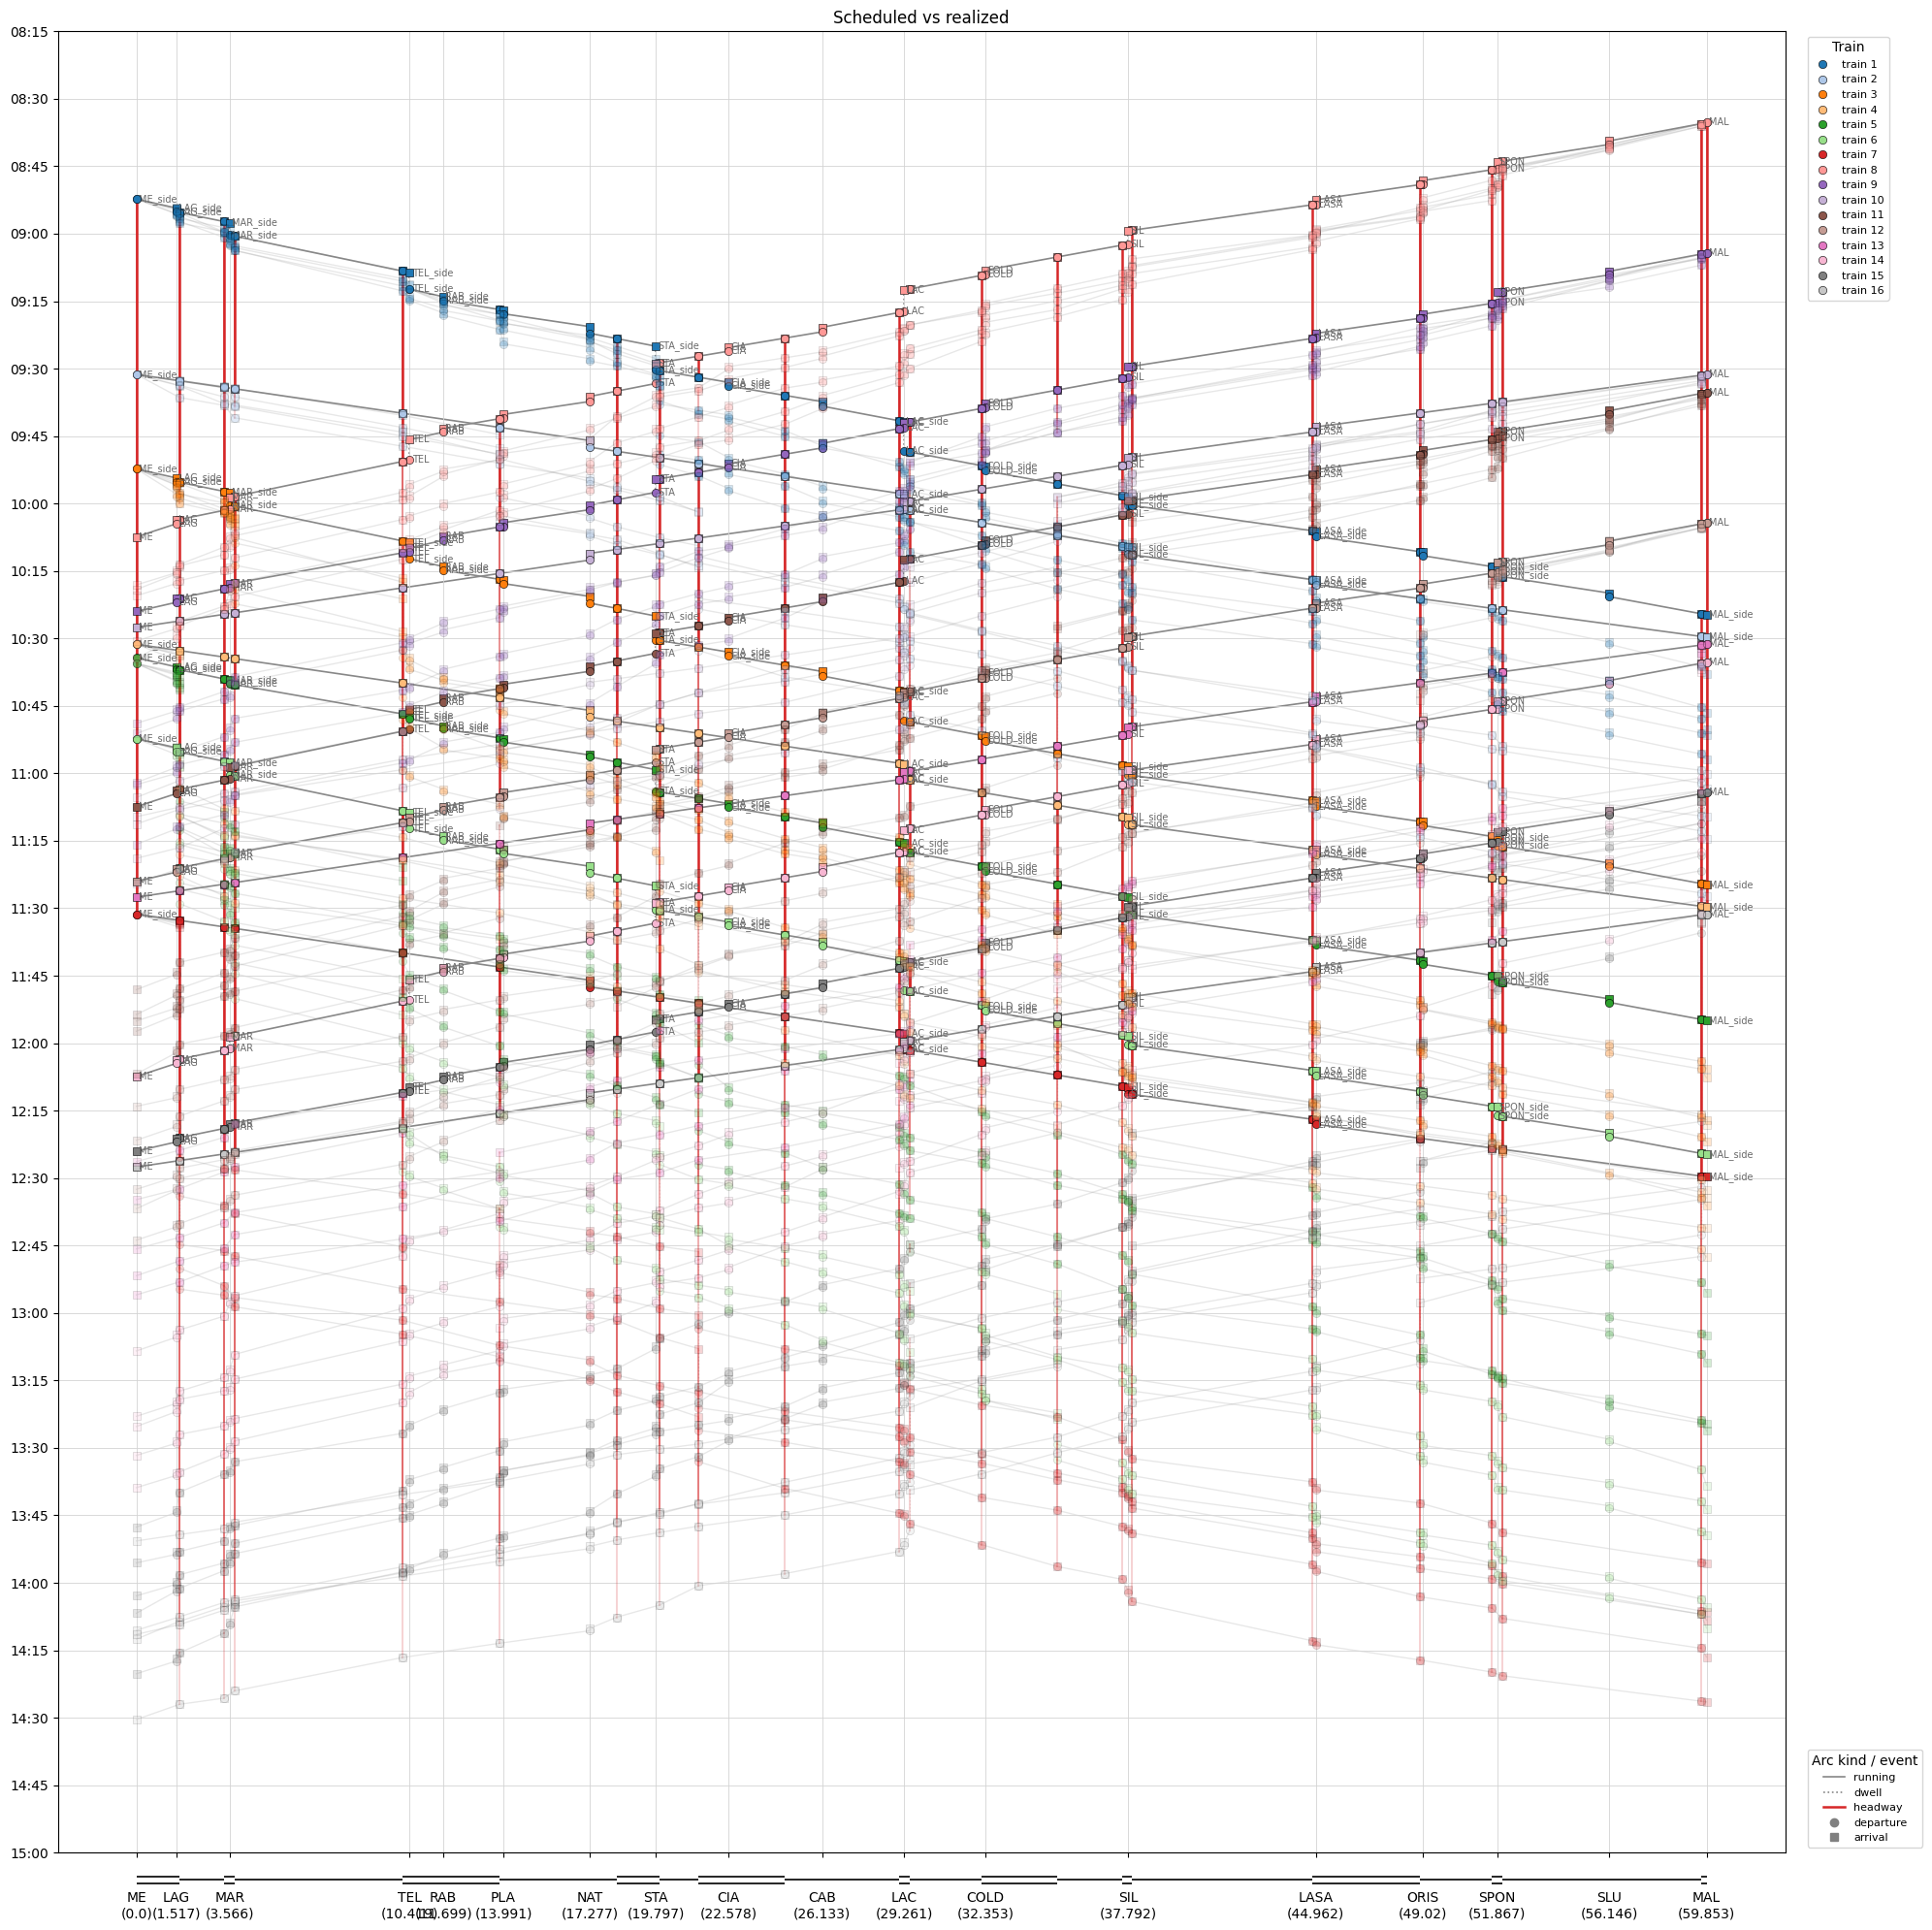

In [ ]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations, edge_perturbations):

    G_realized = propagate2(
        G_scheduled,
        edge_perturbations=edge_p,
        node_perturbations=node_p,
    )

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled,nodesDf,edgesDf,title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

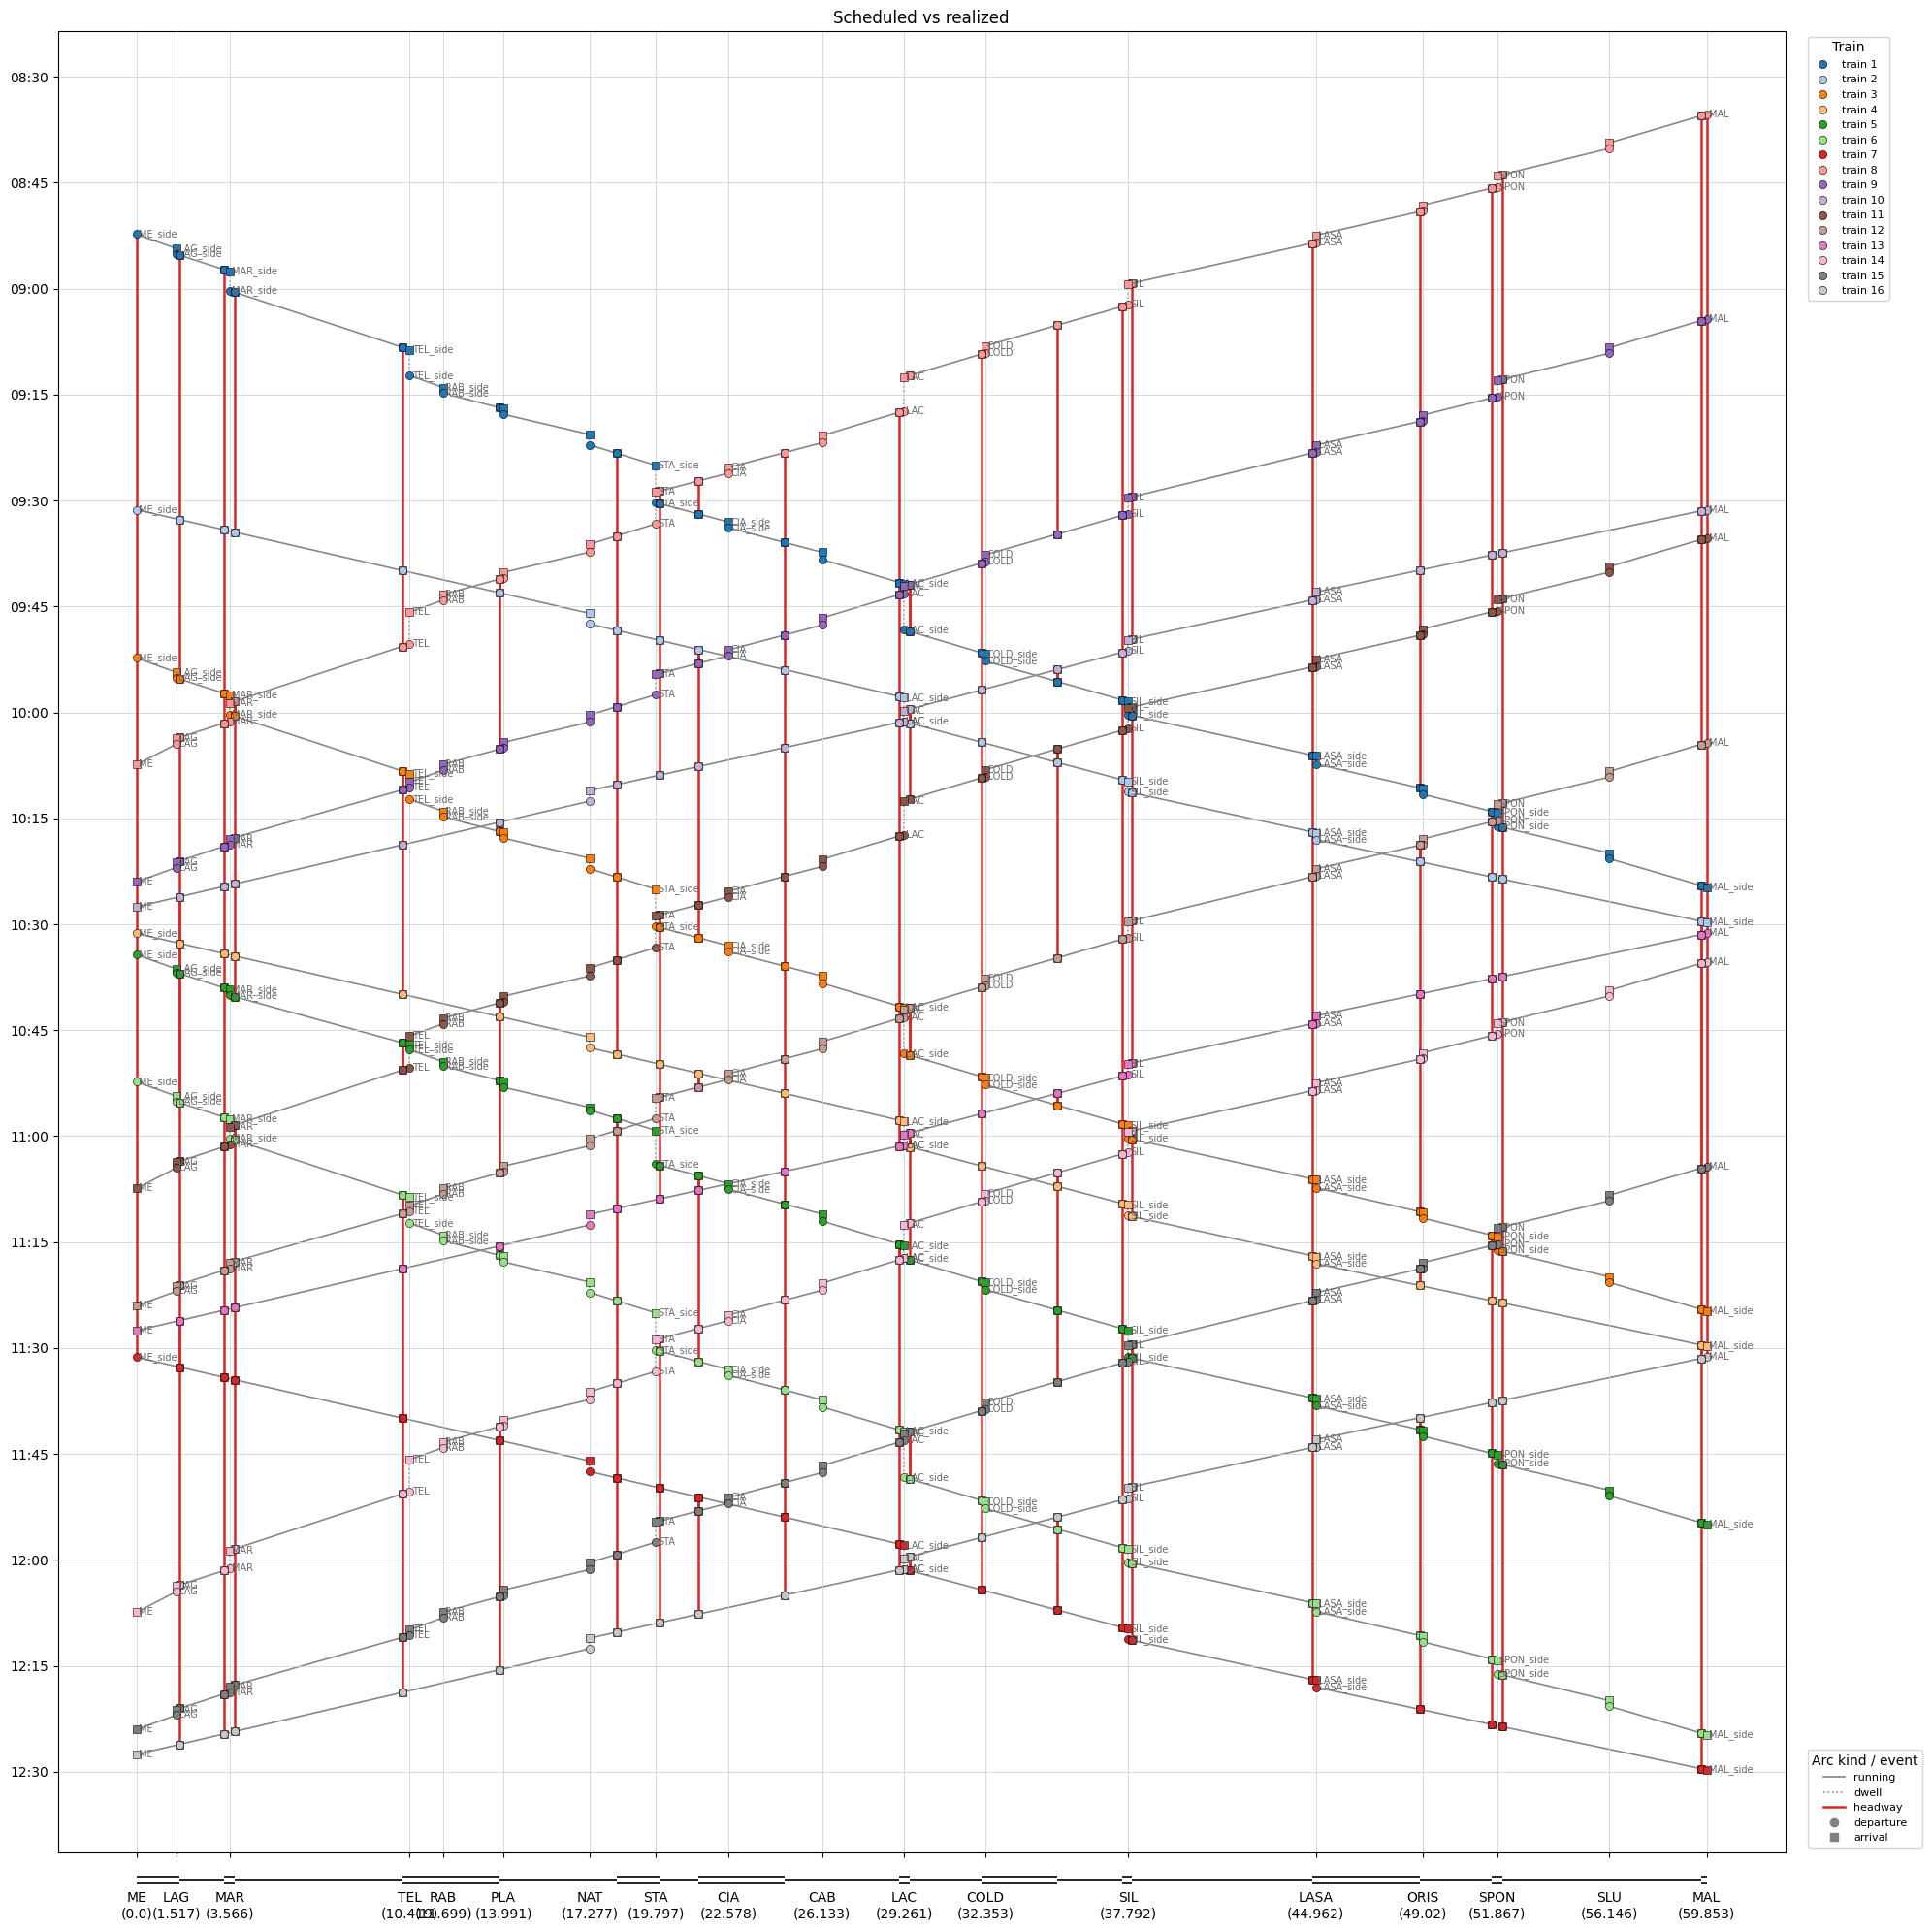

In [ ]:
#inject delays manually
'''running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]
edge = running_edges[0]  

perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = {}


realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)'''

In [36]:
def compute_train_durations(G):
    """
    Returns
    -------
    dict
        {train_id: duration (timedelta)}
    """
    durations = {}
    trains = sorted({data["train"] for _, data in G.nodes(data=True) if "train" in data})

    for train in trains:
        events = [data for _, data in G.nodes(data=True) if data.get("train") == train]
        dep = min(e["time"] for e in events if e["event"] == "dep")
        arr = max(e["time"] for e in events if e["event"] == "arr")
        durations[train] = arr - dep
        
    return durations

In [37]:
def compare_to_schedule(G_scheduled, G_realized):
    scheduled = compute_train_durations(G_scheduled)
    realized = compute_train_durations(G_realized)
    report = {}
    for train in scheduled:
        report[train] = {"scheduled": scheduled[train], "realized": realized[train], "extra_time": realized[train] - scheduled[train]}
    return report

In [39]:
scheduled = compute_train_durations(G_scheduled)

for i, (perturbation, G_realized) in enumerate(zip(perturbations, realized_graphs)):
    realized = compute_train_durations(G_realized)
    primary = sum(perturbation.values()) if perturbation else 0
    print(f"\nPerturbation {i}  (primary delay = {primary:.0f} s)")
    print("-" * 45)
    secondary = 0
    for train in sorted(scheduled):
        extra = realized[train] - scheduled[train]
        # primary delay belongs to the perturbed train only
        propagated = extra - primary if train == 1 else extra
        secondary += max(0, propagated)
        print(
            f"Train {train:>2}: "
            f"scheduled={scheduled[train]:6.0f}s  "
            f"realized={realized[train]:6.0f}s  "
            f"Δ={extra:5.0f}s"
        )

    avg_pri = primary/len(realized)
    avg_sec = secondary/len(realized)
    
    print(f"\n Total primary delay   : {primary:.0f} s")
    print(f"Total secondary delay : {secondary:.0f} s")
    print(f"\n Average primary delay   : {avg_pri:.0f} s")
    print(f"Average secondary delay   : {avg_sec:.0f} s")